In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt
from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
            plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, \
            plot_all_features_in_2d_array, plot_latent_evolution_grid, read_yaml_params
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from typing import Optional
import seaborn as sns

import gudhi
import cProfile


eps=0.00/2.47 | edges=0/3160 | triangles=0/82160 | Betti #: B0=80, B1=0
eps=0.05/2.47 | edges=9/3160 | triangles=1/82160 | Betti #: B0=72, B1=0
eps=0.10/2.47 | edges=35/3160 | triangles=6/82160 | Betti #: B0=50, B1=0
eps=0.15/2.47 | edges=70/3160 | triangles=29/82160 | Betti #: B0=31, B1=0
eps=0.20/2.47 | edges=131/3160 | triangles=100/82160 | Betti #: B0=13, B1=0
eps=0.25/2.47 | edges=177/3160 | triangles=194/82160 | Betti #: B0=7, B1=0
eps=0.30/2.47 | edges=251/3160 | triangles=377/82160 | Betti #: B0=3, B1=0
eps=0.35/2.47 | edges=311/3160 | triangles=581/82160 | Betti #: B0=1, B1=0
eps=0.40/2.47 | edges=383/3160 | triangles=896/82160 | Betti #: B0=1, B1=0
eps=0.45/2.47 | edges=438/3160 | triangles=1194/82160 | Betti #: B0=1, B1=0
eps=0.50/2.47 | edges=476/3160 | triangles=1426/82160 | Betti #: B0=1, B1=0
eps=0.55/2.47 | edges=533/3160 | triangles=1804/82160 | Betti #: B0=1, B1=0
eps=0.60/2.47 | edges=592/3160 | triangles=2235/82160 | Betti #: B0=1, B1=0
eps=0.65/2.47 | edges=645/316

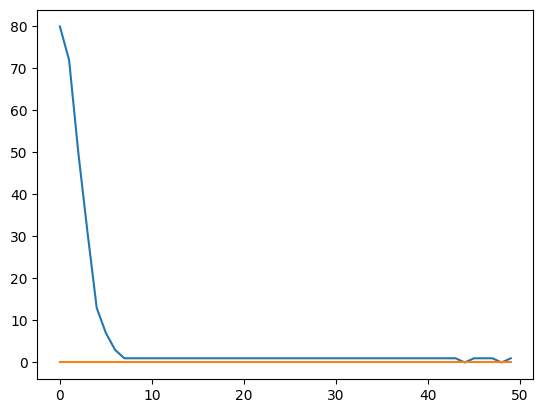

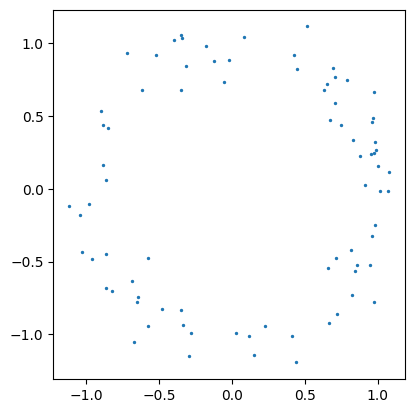

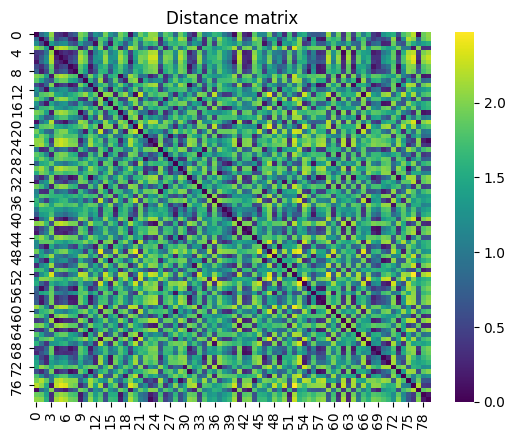

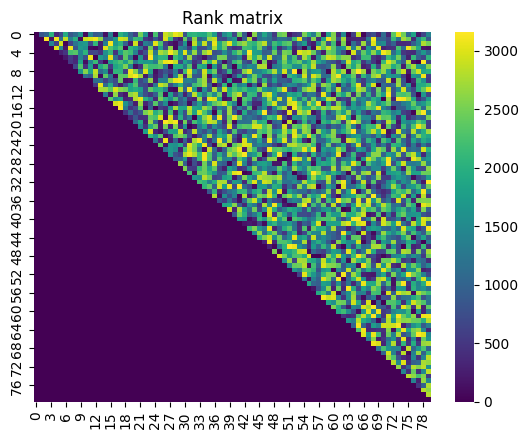

In [47]:

def generate_torus_like_point_cloud_torch(n_points: int = 2000, R: float = 1.0, r: float = 0.3, noise: float = 0.01, seed: Optional[int] = None, device: str = "cuda", dtype: torch.dtype = torch.float32) -> torch.Tensor:
    """Generate a 2D torus-like (ring) point cloud on GPU using PyTorch."""
    if seed is not None:
        torch.manual_seed(seed)

    theta = torch.rand(n_points, device=device, dtype=dtype) * (2 * torch.pi)
    radial = R + r * torch.randn(n_points, device=device, dtype=dtype)
    x = radial * torch.cos(theta)
    y = radial * torch.sin(theta)
    pts = torch.stack([x, y], dim=1)
    pts = pts + noise * torch.randn_like(pts)
    return pts

def pairwise_dist_gpu(X: torch.Tensor) -> torch.Tensor:
    """GPU pairwise distances using Gram trick."""
    G = X @ X.T
    sq = (X**2).sum(dim=1, keepdim=True)
    D2 = sq + sq.T - 2*G
    D2 = torch.clamp(D2, min=0.0)
    return torch.sqrt(D2)

def adjacency_from_distance_matrix(D: torch.Tensor, epsilon: float) -> torch.Tensor:
    """Binary adjacency matrix from distance matrix."""
    A = (D < epsilon) & (D > 0.0)

    # enforce symmetry + remove diagonal
    A = torch.triu(A, diagonal=1)
    A = A | A.T

    return A

def count_edges(A: torch.Tensor) -> int:
    """Count undirected edges."""
    return int(torch.triu(A, diagonal=1).sum().item())

def count_triangles(A: torch.Tensor) -> int:
    """Count undirected triangles.
    trace(A^3)/6:
    - each triangle appears 6 times"""
    Af = A.float()
    A3 = Af @ Af @ Af
    return int(torch.trace(A3).item() / 6)

def compute_betti_0(adj: torch.Tensor, tol: float = 1e-5) -> int:
    """Connected components via Laplacian spectrum. Betti-0 via graph Laplacian.. B0 = vertices - rank."""
    A = adj.float()
    degree = torch.diag(A.sum(dim=1))
    L = degree - A
    eigvals = torch.linalg.eigvalsh(L)
    return int((eigvals < tol).sum().item())

def compute_betti_1(V: int, E: int, C: int, T: int) -> int:
    """Approximate Betti-1. B1 = edges + connected components - triangles - vertices"""
    return max(E - V + C - T, 0)


n_points     = 80
point_cloud  = generate_torus_like_point_cloud_torch(n_points, R=1.0, r=0.10, noise=0.005, seed=4, device="cuda")
dist_matrix_orig = pairwise_dist_gpu(point_cloud)

D        = dist_matrix_orig.clone()
max_dist = D.max().item()
n_observed_edges = 0

eps  = 0
step = 0.05

B0_arr, B1_arr = [], []

while eps <= max_dist:
    adj     = adjacency_from_distance_matrix(D, eps)
    n_edges = count_edges(adj)
    n_triangles = count_triangles(adj)
    
    B0 = compute_betti_0(adj)
    B1 = compute_betti_1(V=n_points, E=n_edges, C=B0, T=n_triangles)
    B0_arr.append(B0)
    B1_arr.append(B1)

    print(f"eps={eps:.2f}/{max_dist:.2f} | "
        f"edges={n_edges}/{n_points*(n_points-1)//2} | "
        f"triangles={n_triangles}/{math.comb(n_points, 3)} | "
        f"Betti #: B0={B0}, B1={B1}")
    eps += step

plt.figure()
# plt.plot(np.arange(len(B0_arr)) * step, B0_arr, label='B0')
# plt.plot(np.arange(len(B1_arr)) * step, B1_arr, label='B1')
plt.plot(B0_arr)
plt.plot(B1_arr)
plt.show()

# ===============
plt.scatter(point_cloud[:, 0].cpu(), point_cloud[:, 1].cpu(), s=2)
plt.gca().set_aspect('equal')
plt.show()
plt.figure()
sns.heatmap(D.cpu(), cmap='viridis')
plt.title("Distance matrix")

plt.figure()
sns.heatmap(dist_ranks.cpu(), cmap='viridis')
plt.title("Rank matrix")
plt.show()


In [ ]:
M      = np.array([[0, 1, 1, 0],
                   [1, 0, 1, 0],
                   [1, 1, 0, 0],
                   [0, 0, 0, 0]])
M2      = M@M
M_bool  = M.astype(bool)
M2_bool = (M2 > 0)

triangles = M2_bool & M_bool  # shared friend AND direct edge
np.fill_diagonal(triangles, False)  # ignore diagonal

print("M2:\n", M2)
print("Triangles matrix:\n", triangles)